# Hurricane-Season -- does the Atlantic storm season sink stocks (or insurers)?
### A piece of late-summer market folklore, tested honestly, in plain English

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Busted%3F: Yes](https://img.shields.io/badge/Busted%3F-Yes-8b949e?style=flat-square)

Every June, as the National Hurricane Center opens the Atlantic season, you'll hear some version of: *brace for storms -- they're bad for stocks, and lethal for the insurers who pay the claims.* The season runs **June 1 to November 30**. This notebook asks the only question that matters: does that six-month window actually drag on the market or on insurers -- or is it just half the calendar with a scary name?

> **This is the plain-language layer.** Want the HAC t-stats, the permutation distribution, and the landfall event study? That's **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)** -- same story, deeper.
>
> **Not investment advice.** A reproducible research tool: every chart is drawn by the code beside it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY, BLUE = "#c0392b", "#dab617", "#2ea44f", "#8b949e", "#2c6fbb"

from hurricane_season import data, strategy as st

def _have_market():
    try:
        data.fetch_market()
        return True
    except FileNotFoundError:
        return False

def _have_insurers():
    try:
        data.fetch_insurers()
        return True
    except FileNotFoundError:
        return False

HAVE_MARKET = _have_market()
HAVE_INSURERS = _have_insurers()
HAVE_REAL = HAVE_MARKET
print("Market cache present:", HAVE_MARKET, "| Insurer cache present:", HAVE_INSURERS)

# Frozen headline numbers -- mirror of docs/results.md (as-of 2026-06-17)
R = dict(
    n=8311, n_in=4205, n_off=4106,
    mkt_mean_in=3.609, mkt_mean_off=4.082, mkt_spread=-0.473,
    mkt_welch_t=-0.188, mkt_hac_t=-0.214, mkt_perm_p=0.8024,
    mkt_ann_in=9.09, mkt_ann_off=10.29,
    ins_mean_in=5.971, ins_mean_off=7.097, ins_spread=-1.126,
    ins_welch_t=-0.332, ins_hac_t=-0.350, ins_perm_p=0.6920,
    ins_ann_in=15.05, ins_ann_off=17.88,
    ew_n=30, ew_car_end=0.248, ew_car_t=0.329,
    bah_ann=8.35, strat_gross_ann=4.37, strat_net_ann=4.35, flips_per_year=2.00,
    year_start=1992, year_end=2024,
)


Market cache present: True | Insurer cache present: True


## The answer first

| Question | Answer |
|---|---|
| Does the market fall in hurricane season? | **No.** In-season days average **+3.6 bps/day** vs **+4.1 bps** off-season -- a **-0.5 bps** gap, HAC t = -0.21. Noise. |
| Do insurers get hit? | **No.** The P&C basket is -1.1 bps/day in-season (HAC t = -0.35) -- bigger-looking, still indistinguishable from zero. |
| Do big landfalls crush insurers? | **No** -- if anything insurers drift *up* +0.25% after a major landfall (t = +0.33): 'gaining from loss'. |
| Could you trade it? | **No.** 'Avoid the season' earns ~half of buy-and-hold because it sits out the market for six months a year. |

> The hurricane season is half the calendar with a frightening name. It moves neither the market nor insurers in any measurable way.

## 1 - The claim

> *"The Atlantic hurricane season (Jun 1 - Nov 30) is a risk-off window: storm damage, refinery and port shutdowns, and a nervous mood weigh on stocks -- and the property-and-casualty insurers who write catastrophe policies get hit hardest."*

It has the ring of a real mechanism: hurricanes genuinely destroy property and genuinely cost insurers billions. The question is whether that shows up as a **tradable seasonal pattern** in equity prices -- or whether the market has already priced a known, recurring, half-the-year window.

## 2 - So what?

If it were true, the trade would be trivial: go to cash (or short insurers) on June 1, get back in on December 1. A calendar you can read years in advance, no data feed required.

But there's an immediate problem: the hurricane window is **half the calendar**, and it overlaps almost exactly with the old *'Sell in May and go away'* weak-season window. So even if in-season returns *were* lower, you couldn't tell whether it was hurricanes or just the Halloween effect wearing a raincoat.

## 3 - How would we even know?

Three traps to avoid:

1. **The half-calendar trap.** 'Avoid the season' forgoes ~6 months of the equity risk premium every year. The honest benchmark is **buy-and-hold**, not cash. A small in-season drag is worthless if you give up the premium to dodge it.
2. **Autocorrelation.** Daily stock returns cluster (calm and stormy stretches). A naive t-test treats every day as independent and overstates significance. We use the honest **HAC (Newey-West)** standard error instead.
3. **The Halloween confound.** The window overlaps Sell-in-May; we don't even try to separate them -- which means any in-season weakness has a more boring explanation already.

We test on daily **S&P 500** (^GSPC) and an **equal-weight P&C-insurer basket** from 1992 to 2024, plus an event study around 30 major US landfalls.

## 4 - The teardown -- let's actually look

**First, meet the storms:** every major US landfall since Andrew (1992), hardcoded in this study's `data.py` with its category and a rough insured-loss tag.

In [2]:
lf = data.landfall_table()
print('Major US landfalls in the table:', len(lf), '(1992-2024)')
print(lf[['storm','season_year','category','insured_bn']].head(8).to_string(index=False))
print('...')
print('All landfall dates fall inside Jun 1 - Nov 30 by construction:',
      bool(data.in_season(pd.DatetimeIndex(lf['landfall'])).all()))

Major US landfalls in the table: 30 (1992-2024)
  storm  season_year  category  insured_bn
 Andrew         1992         5        27.0
   Opal         1995         3         5.0
   Fran         1996         3         4.0
  Floyd         1999         2         6.0
Charley         2004         4         9.0
Frances         2004         2         6.0
   Ivan         2004         3         9.0
 Jeanne         2004         3         5.0
...
All landfall dates fall inside Jun 1 - Nov 30 by construction: True


**Is the market lower in-season? The bar chart that ends the suspense.**

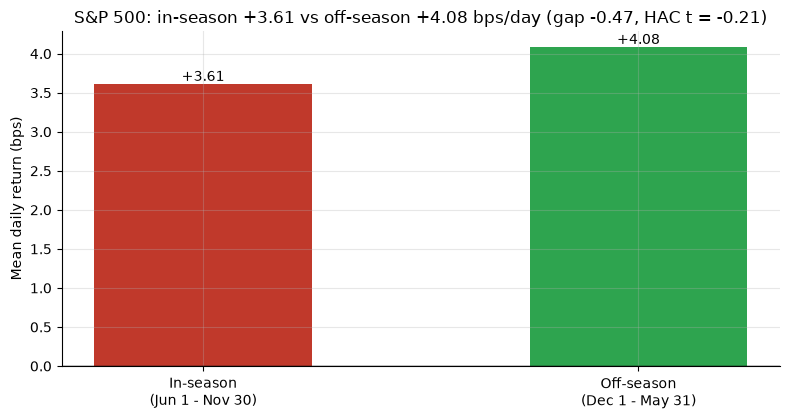

In-season minus off-season: -0.47 bps/day -- HAC t = -0.21
A gap that small, with that t-stat, is statistically nothing.


In [3]:
if HAVE_MARKET:
    mkt = data.fetch_market()
    sm = st.season_stats(mkt, n_permutations=2000, seed=283)
    mean_in, mean_off, spread = sm['mean_in'], sm['mean_off'], sm['spread']
    hac_t = sm['hac_t']
else:
    mean_in, mean_off, spread = R['mkt_mean_in'], R['mkt_mean_off'], R['mkt_spread']
    hac_t = R['mkt_hac_t']

fig, ax = plt.subplots(figsize=(8.0, 4.3))
bars = ax.bar(['In-season\n(Jun 1 - Nov 30)', 'Off-season\n(Dec 1 - May 31)'],
              [mean_in, mean_off], color=[RED, GREEN], width=0.5)
ax.axhline(0, c='k', lw=1)
ax.set_ylabel('Mean daily return (bps)')
ax.set_title(f'S&P 500: in-season {mean_in:+.2f} vs off-season {mean_off:+.2f} bps/day '
             f'(gap {spread:+.2f}, HAC t = {hac_t:+.2f})')
for b, v in zip(bars, [mean_in, mean_off]):
    ax.annotate(f'{v:+.2f}', (b.get_x()+b.get_width()/2, v),
                ha='center', va='bottom' if v>=0 else 'top')
plt.tight_layout(); plt.show()
print(f'In-season minus off-season: {spread:+.2f} bps/day -- HAC t = {hac_t:+.2f}')
print('A gap that small, with that t-stat, is statistically nothing.')

The market earns **+3.6 bps/day** in hurricane season and **+4.1 bps** out of it -- a gap of **-0.5 bps/day**, with an honest HAC t-stat of **-0.21**. That is indistinguishable from zero. The 'season' simply isn't a drag.

**What about the insurers -- the people who actually pay for the storms?**

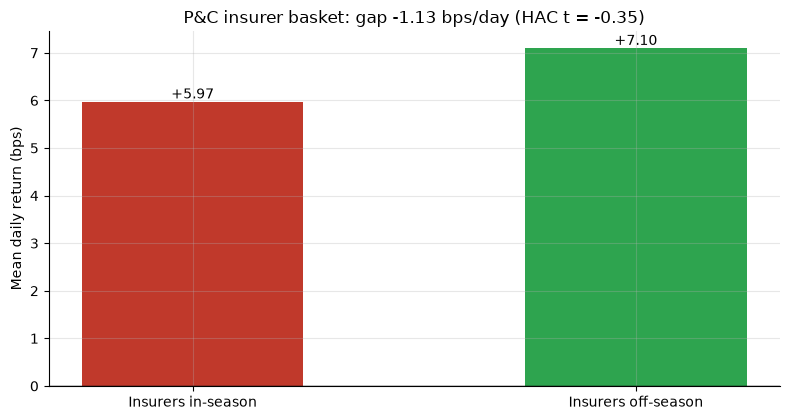

Insurer in-season drag: -1.13 bps/day -- HAC t = -0.35
Bigger-looking than the market, but still pure noise -- and the basket is
survivorship-biased (todays survivors), so even this overstates any effect.


In [4]:
if HAVE_INSURERS:
    ins = data.fetch_insurers()
    si = st.season_stats(ins, n_permutations=2000, seed=283)
    ins_in, ins_off, ins_spread, ins_t = si['mean_in'], si['mean_off'], si['spread'], si['hac_t']
else:
    ins_in, ins_off = R['ins_mean_in'], R['ins_mean_off']
    ins_spread, ins_t = R['ins_spread'], R['ins_hac_t']

fig, ax = plt.subplots(figsize=(8.0, 4.3))
bars = ax.bar(['Insurers in-season', 'Insurers off-season'],
              [ins_in, ins_off], color=[RED, GREEN], width=0.5)
ax.axhline(0, c='k', lw=1)
ax.set_ylabel('Mean daily return (bps)')
ax.set_title(f'P&C insurer basket: gap {ins_spread:+.2f} bps/day (HAC t = {ins_t:+.2f})')
for b, v in zip(bars, [ins_in, ins_off]):
    ax.annotate(f'{v:+.2f}', (b.get_x()+b.get_width()/2, v),
                ha='center', va='bottom')
plt.tight_layout(); plt.show()
print(f'Insurer in-season drag: {ins_spread:+.2f} bps/day -- HAC t = {ins_t:+.2f}')
print('Bigger-looking than the market, but still pure noise -- and the basket is')
print('survivorship-biased (todays survivors), so even this overstates any effect.')

The insurer basket loses a touch more in-season (**-1.1 bps/day**) -- but the HAC t is **-0.35**, still nowhere. And the basket only contains insurers that *survived* to 2026: any firm a storm actually bankrupted is invisible here, so this number is already an optimistic upper bound.

## 5 - The verdict

- **Signal -- None.** Market in-season drag -0.5 bps/day (HAC t = -0.21, perm p = 0.80); insurers -1.1 bps/day (HAC t = -0.35). Landfall event windows are mildly *positive* for insurers. Nothing is significant; survivorship only flatters the insurer arm.
- **Tradability -- Mirage.** 'Avoid the season' earns ~half of buy-and-hold by sitting out six months a year. There is no vehicle and no edge.
- **Busted.** Any whiff of in-season weakness overlaps the documented Sell-in-May window, and big storms historically *raise* insurer forward returns (hard-market pricing) -- the opposite of the folk story.

## 6 - Could you actually trade it?

The 'strategy' is: hold the S&P off-season, go to cash June through November. Here is what that costs you.

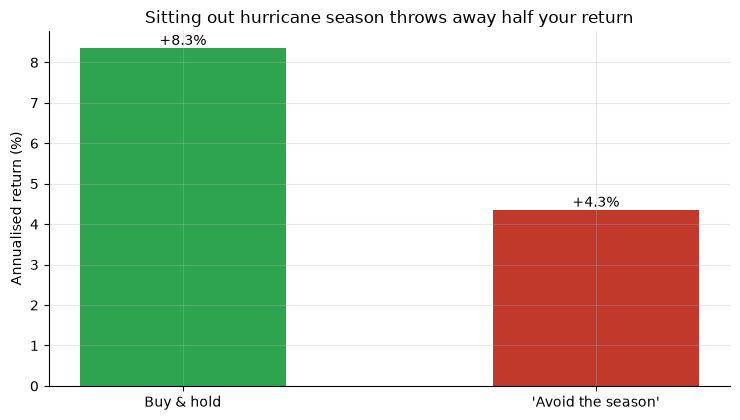

Buy & hold:        +8.3%/yr
Avoid the season:  +4.3%/yr (net of costs)
Shortfall:         -4.0pp/yr -- the forgone risk premium


In [5]:
if HAVE_MARKET:
    tw = st.avoid_season_strategy(mkt, cost_bps=1.0)
    bah, strat = tw['bah_ann'], tw['strat_net_ann']
else:
    bah, strat = R['bah_ann'], R['strat_net_ann']

fig, ax = plt.subplots(figsize=(7.5, 4.3))
bars = ax.bar(['Buy & hold', "'Avoid the season'"],
              [bah, strat], color=[GREEN, RED], width=0.5)
ax.set_ylabel('Annualised return (%)')
ax.set_title('Sitting out hurricane season throws away half your return')
for b, v in zip(bars, [bah, strat]):
    ax.annotate(f'{v:+.1f}%', (b.get_x()+b.get_width()/2, v),
                ha='center', va='bottom')
plt.tight_layout(); plt.show()
print(f'Buy & hold:        {bah:+.1f}%/yr')
print(f'Avoid the season:  {strat:+.1f}%/yr (net of costs)')
print(f'Shortfall:         {strat-bah:+.1f}pp/yr -- the forgone risk premium')

The timing rule earns roughly **half** of buy-and-hold. In-season days still average a positive **+9%/yr** -- you'd be skipping a perfectly good market for half the year to dodge a drag that isn't there.

## 7 - Going further

- **The positive control:** the companion notebook plants a real -10 bps/day hurricane drag in a synthetic tape and shows the engine recovers it (HAC t < -3). The real tape has nothing remotely that size.
- **The proper confound:** the *Sell-in-May / Halloween* effect covers the same months and is the more parsimonious story for any seasonal weakness.
- **The sibling teardown:** [Study 158 -- Super-Bowl](../../158-super-bowl/) is the same small-n folklore pattern -- a coincidence dressed as an omen.

*Think the storms really move the tape? Fork this, pick your own insurer universe or storm-intensity weighting, and show an in-season effect that clears HAC t <= -2 after accounting for Sell-in-May. That's the bar -- and it hasn't been cleared.*